In [1]:
from pathlib import Path
from tempfile import TemporaryDirectory

import pandas as pd

import scarf
from scarf.tools.repack_zarr import repack_store

scarf.configure_output(level='WARNING', progress=True)

In [2]:
dataset = scarf.cytebase.connect("scarf_docs").download_dataset(
    name='bastidas-ponce_4K_pancreas-d15_rnaseq',
    destination='scarf_datasets',
    zarr=True,
)

analysis_directory = TemporaryDirectory()
repacked_counts_path = Path(analysis_directory.name) / 'counts.zarr'
analysis_path = Path(analysis_directory.name) / 'data_organization.zarr'
repack_store(
    f'{dataset}/data.zarr',
    str(repacked_counts_path),
    nthreads=2,
)
ds = scarf.mount_datastore(
    str(repacked_counts_path),
    at=str(analysis_path),
    default_assay='RNA',
    nthreads=4,
)

hvg_ref = ds.mark_hvgs(min_cells=20, top_n=500, show_plot=False)
normalized = ds.run_normalization(features=hvg_ref)
all_features = ds.resolve_features('RNA', 'all_features')
marker_ref = ds.run_marker_search(
    group_key='clusters',
    cell_key='I',
    features=all_features,
)

ds

Downloading bucket files: 43423201 / 43423201 complete

Downloading bytes: 43423201 / 43423201 complete

Repacking RNA/counts: 1 / 1 complete

Repacking RNA/artifacts/embedding//values: 1 / 1 complete

Repacking RNA/artifacts/embedding_initialization//cluster_centers: 1 / 1 complete

...

  RNA/counts: shape=(3696, 27998), dtype=uint16, chunks=(3696, 13528), shards=(3696, 40584)


Calculating feature statistics: 4 / 4 complete

Writing data: 1 / 1 complete

Finding markers: 2 / 2 complete

DataStore has 3696 (3696) cells with 1 assays: RNA
   Cell metadata:
            'I', 'ids', 'names', 'RNA_nFeatures', 'RNA_percentMito', 
            'RNA_nCounts', 'RNA_clusters', 'clusters_coarse', 'RNA_percentRibo', 'G2M_score', 
            'X_umap1', 'X_umap2', 'RNA_UMAP1', 'RNA_UMAP2', 'clusters', 
            'RNA_leiden_cluster', 'S_score'
   RNA assay has 27998 features and following metadata:
            'I', 'ids', 'names', 'nCells', 'all_features', 
            'dropOuts', 'highly_variable_genes', 'hvgs'

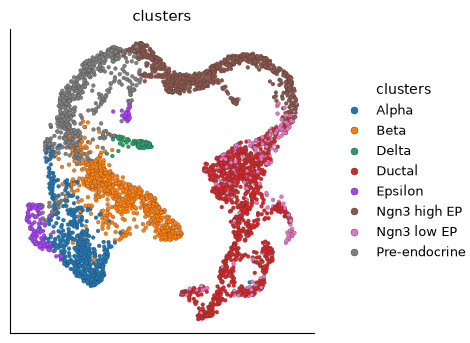

In [3]:
ds.plots.embedding(
    layout_key='RNA_UMAP',
    color_by='clusters',
)

In [4]:
ds.show_zarr_tree(depth=1)

/
├── RNA
│   ├── artifacts
│   ├── featureData
│   ├── markers
│   └── state
├── artifacts
│   ├── cell_selection
│   └── metadata_snapshot
└── cellData
    ├── G2M_score (3696,) float32
    ├── I (3696,) bool
    ├── RNA_UMAP1 (3696,) float32
    ├── RNA_UMAP2 (3696,) float32
    ├── RNA_clusters (3696,) int64
    ├── RNA_leiden_cluster (3696,) int64
    ├── RNA_nCounts (3696,) float64
    ├── RNA_nFeatures (3696,) float64
    ├── RNA_percentMito (3696,) float64
    ├── RNA_percentRibo (3696,) float64
    ├── S_score (3696,) float32
    ├── X_umap1 (3696,) float32
    ├── X_umap2 (3696,) float32
    ├── clusters (3696,) <U13
    ├── clusters_coarse (3696,) <U13
    ├── ids (3696,) <U16
    └── names (3696,) <U16



In [5]:
ds.show_zarr_tree(start='cellData')

/cellData
├── G2M_score (3696,) float32
├── I (3696,) bool
├── RNA_UMAP1 (3696,) float32
├── RNA_UMAP2 (3696,) float32
├── RNA_clusters (3696,) int64
├── RNA_leiden_cluster (3696,) int64
├── RNA_nCounts (3696,) float64
├── RNA_nFeatures (3696,) float64
├── RNA_percentMito (3696,) float64
├── RNA_percentRibo (3696,) float64
├── S_score (3696,) float32
├── X_umap1 (3696,) float32
├── X_umap2 (3696,) float32
├── clusters (3696,) <U13
├── clusters_coarse (3696,) <U13
├── ids (3696,) <U16
└── names (3696,) <U16

  I: shape=(3696,), dtype=bool, chunks=(100000,)
  RNA_percentRibo: shape=(3696,), dtype=float64, chunks=(100000,)
  RNA_percentMito: shape=(3696,), dtype=float64, chunks=(100000,)
  X_umap1: shape=(3696,), dtype=float32, chunks=(100000,)
  RNA_nCounts: shape=(3696,), dtype=float64, chunks=(100000,)
  RNA_nFeatures: shape=(3696,), dtype=float64, chunks=(100000,)
  names: shape=(3696,), dtype=<U16, chunks=(100000,)
  G2M_score: shape=(3696,), dtype=float32, chunks=(100000,)
  RNA_clu

In [6]:
ds.cells.to_pandas_dataframe(['I'])['I'].value_counts()

I
True    3696
Name: count, dtype: int64

In [7]:
ds.show_zarr_tree(start='RNA', depth=1)

/RNA
├── artifacts
│   ├── feature_selection
│   ├── feature_summary
│   ├── marker_table
│   └── normalized
├── featureData
│   ├── I (27998,) bool
│   ├── all_features (27998,) bool
│   ├── dropOuts (27998,) int64
│   ├── highly_variable_genes (27998,) <U5
│   ├── hvgs (27998,) bool
│   ├── ids (27998,) <U15
│   ├── nCells (27998,) int64
│   └── names (27998,) <U15
├── markers
└── state



In [8]:
ds.show_zarr_tree(start='RNA/featureData', depth=1)

/RNA/featureData
├── I (27998,) bool
├── all_features (27998,) bool
├── dropOuts (27998,) int64
├── highly_variable_genes (27998,) <U5
├── hvgs (27998,) bool
├── ids (27998,) <U15
├── nCells (27998,) int64
└── names (27998,) <U15

  ids: shape=(27998,), dtype=<U15, chunks=(100000,)
  highly_variable_genes: shape=(27998,), dtype=<U5, chunks=(100000,)
  I: shape=(27998,), dtype=bool, chunks=(100000,)
  all_features: shape=(27998,), dtype=bool, chunks=(27998,)


  hvgs: shape=(27998,), dtype=bool, chunks=(27998,)
  nCells: shape=(27998,), dtype=int64, chunks=(100000,)
  dropOuts: shape=(27998,), dtype=int64, chunks=(100000,)
  names: shape=(27998,), dtype=<U15, chunks=(100000,)


In [9]:
ds.show_zarr_tree(start='RNA/artifacts', depth=1)

/RNA/artifacts
├── feature_selection
│   ├── 2ea24cc630b5066a61a2d55f4f61faa99e9d8c4e72c444ec39a3996afa0dbaa7
│   └── 94a6a8604c8d39f3aadf42412172280eab92c646b45ca045d07c5bcd62def43e
├── feature_summary
│   └── 376d77e1bdb7f5ac1ab6a74069a96c13de4e0693975385bffde3f044d7d9c479
├── marker_table
│   └── f0e7e8599157c2bc915a34b04a13bbd6bc4ffd0e19d9697b53c87ddafaf36f07
└── normalized
    └── 05283b8a5872f283d5f6e624b943c357695a9de3792faf58c9c030dce06719f6



In [10]:
ds.cells.head()

,I,ids,names,X_umap1,RNA_percentRibo,G2M_score,RNA_percentMito,RNA_nFeatures,RNA_clusters,clusters_coarse,S_score,RNA_leiden_cluster,X_umap2,RNA_nCounts,RNA_UMAP1,clusters,RNA_UMAP2
0,True,AAACCTGAGAGGGATA,AAACCTGAGAGGGATA,6.143066,15.563181,-0.252071,0.706500,2356.0,5,Pre-endocrine,-0.224902,5,-0.063644,4954.0,-22.176723,Pre-endocrine,5.158421
1,True,AAACCTGAGCCTTGAT,AAACCTGAGCCTTGAT,-9.906417,30.632160,-0.232610,1.286947,2613.0,1,Ductal,-0.014707,1,0.197778,7071.0,13.041407,Ductal,-4.812334
2,True,AAACCTGAGGCAATTA,AAACCTGAGGCAATTA,7.559791,19.041769,-0.286834,0.687961,1984.0,5,Endocrine,-0.171255,5,0.583762,4070.0,-26.320560,Alpha,-4.607774
3,True,AAACCTGCATCATCCC,AAACCTGCATCATCCC,-11.283765,28.653432,0.191243,1.195886,2860.0,6,Ductal,0.599244,6,4.218998,8362.0,12.318944,Ductal,-22.613249
4,True,AAACCTGGTAAGTGGC,AAACCTGGTAAGTGGC,1.721565,19.419021,-0.126030,1.094310,2211.0,7,Ngn3 high EP,-0.179981,7,-4.753407,5026.0,-7.786273,Ngn3 high EP,24.942205


In [11]:
ds.RNA.feats.head()

,I,ids,names,all_features,highly_variable_genes,nCells,hvgs,dropOuts
0,True,Xkr4,Xkr4,True,False,6,False,3690
1,True,Gm37381,Gm37381,True,,0,False,3696
2,True,Rp1,Rp1,True,,0,False,3696
3,True,Rp1-1,Rp1-1,True,,0,False,3696
4,True,Sox17,Sox17,True,,0,False,3696


In [12]:
ds.cells.to_pandas_dataframe(
    columns=['ids', 'RNA_nCounts', 'RNA_nFeatures', 'clusters']
).set_index('ids')

,RNA_nCounts,RNA_nFeatures,clusters
ids,,,
AAACCTGAGAGGGATA,4954.0,2356.0,Pre-endocrine
AAACCTGAGCCTTGAT,7071.0,2613.0,Ductal
AAACCTGAGGCAATTA,4070.0,1984.0,Alpha
AAACCTGCATCATCCC,8362.0,2860.0,Ductal
AAACCTGGTAAGTGGC,5026.0,2211.0,Ngn3 high EP
...,...,...,...
TTTGTCAAGTGACATA,9219.0,3283.0,Pre-endocrine
TTTGTCAAGTGTGGCA,7298.0,2605.0,Ngn3 high EP
TTTGTCAGTTGTTTGG,5234.0,2168.0,Ductal


In [13]:
cluster_labels = ds.cells.fetch('clusters')
first_cluster = str(cluster_labels[0])
is_first_cluster = cluster_labels.astype(str) == first_cluster
ds.cells.insert(column_name='is_first_cluster', values=is_first_cluster, overwrite=True)

In [14]:
ds.cells.to_pandas_dataframe(
    columns=['ids', 'clusters', 'is_first_cluster']
).head()

,ids,clusters,is_first_cluster
0,AAACCTGAGAGGGATA,Pre-endocrine,True
1,AAACCTGAGCCTTGAT,Ductal,False
2,AAACCTGAGGCAATTA,Alpha,False
3,AAACCTGCATCATCCC,Ductal,False
4,AAACCTGGTAAGTGGC,Ngn3 high EP,False


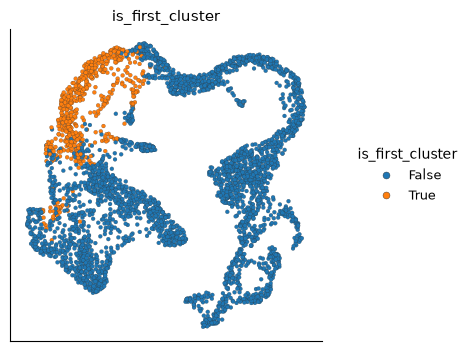

In [15]:
ds.plots.embedding(
    layout_key='RNA_UMAP',
    color_by='is_first_cluster',
)

In [16]:
i_backup = ds.cells.fetch_all('I').copy()
ds.cells.update_key(is_first_cluster, 'I')

print(
    'fetch:', ds.cells.fetch('clusters').shape,
    'fetch_all:', ds.cells.fetch_all('clusters').shape,
)
ds.cells.to_pandas_dataframe(['I'])['I'].value_counts()

fetch: (592,) fetch_all: (3696,)


I
False    3104
True      592
Name: count, dtype: int64

In [17]:
ds.cells.insert(column_name='I', values=i_backup, overwrite=True, force=True)
print('Restored active cells:', int(ds.cells.fetch_all('I').sum()))

Restored active cells: 3696


In [18]:
try:
    ds.cells.insert(
        column_name='is_first_cluster',
        values=is_first_cluster,
    )
except ValueError:
    print("Expected validation: use overwrite=True to replace an existing column.")

Expected validation: use overwrite=True to replace an existing column.


In [19]:
active_before = int(ds.cells.fetch_all('I').sum())
count_range = ds.cells.sift(
    'RNA_nCounts',
    min_v=1000,
    max_v=15000,
)
joint_range = ds.cells.multi_sift(
    columns=['RNA_nCounts', 'RNA_nFeatures'],
    lows=[1000, 500],
    highs=[15000, 4000],
)
cluster_rows = ds.cells.get_index_by([first_cluster], 'clusters')

print(
    'count_range:', int(count_range.sum()),
    'joint_range:', int(joint_range.sum()),
    'cluster_rows:', int(cluster_rows.size),
)
print('Active cells (I) before:', active_before)
print('Active cells (I) after:', int(ds.cells.fetch_all('I').sum()))

count_range: 3669 joint_range: 3667 cluster_rows: 592
Active cells (I) before: 3696
Active cells (I) after: 3696


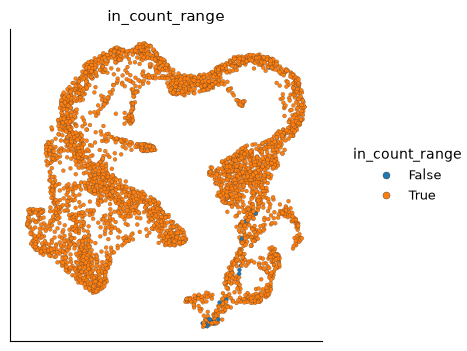

In [20]:
ds.cells.insert(column_name='in_count_range', values=count_range, overwrite=True)
ds.plots.embedding(
    layout_key='RNA_UMAP',
    color_by='in_count_range',
)

In [21]:
ds.RNA.rawData

ChunkedArray(shape=(3696, 27998), dtype=uint16, chunksize=(3696, 27998), numblocks=1)

In [22]:
ds.RNA.normed()

ChunkedArray(shape=(3696, 27998), dtype=float64, chunksize=(3696, 27998), numblocks=1)

In [23]:
print('Raw shape:', ds.RNA.rawData.shape)
print('Normed shape:', ds.RNA.normed().shape)
ds.RNA.rawData[:3, :5].compute()

Raw shape: (3696, 27998)
Normed shape: (3696, 27998)


array([[0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0]], dtype=uint16)

In [24]:
ds.RNA.normed()[:3, :5].compute()

array([[0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.]])

In [25]:
print('Current method:', ds.RNA.normMethod.__name__)

Current method: norm_lib_size


In [26]:
reused_normalized = ds.run_normalization(features=hvg_ref)
print('Reused:', reused_normalized == normalized)
reused_normalized

Reused: True


ArtifactRef(assay='RNA', kind='normalized', artifact_id='05283b8a5872...')

In [27]:
status = ds.inspect_artifact(reused_normalized)
print('Complete:', status.complete)
print('Operation:', status.operation)
print('Parameters:', status.parameters)

group = ds.load_artifact(reused_normalized)
print('Arrays:', list(group.array_keys())[:5])

Complete: True
Operation: run_normalization
Parameters: {'normalization_method': {'external_hook': True, 'module': 'scarf.assay', 'qualname': 'norm_lib_size'}, 'size_factor': 1000.0, 'log_transform': True, 'renormalize_subset': True}
Arrays: ['data', 'feature_sum', 'feature_squared_sum']


In [28]:
index = dict(ds.z['RNA/markers'].attrs.get('artifacts', {}))
index

{'I': {'clusters': {'2ea24cc630b5066a61a2d55f4f61faa99e9d8c4e72c444ec39a3996afa0dbaa7': {'type': 'artifact',
    'scope': 'assay',
    'kind': 'marker_table',
    'artifact_id': 'f0e7e8599157c2bc915a34b04a13bbd6bc4ffd0e19d9697b53c87ddafaf36f07',
    'assay': 'RNA'}}}}

In [29]:
table = scarf.ArtifactRef.from_dict(
    index['I']['clusters'][all_features.artifact_id]
)
print('Stored at:', ds.inspect_artifact(table).path)

Stored at: RNA/artifacts/marker_table/f0e7e8599157c2bc915a34b04a13bbd6bc4ffd0e19d9697b53c87ddafaf36f07


In [30]:
ds.get_markers(
    marker=marker_ref,
    cell_key='I',
    group_key='clusters',
    group_id=ds.cells.fetch('clusters')[0],
    min_score=0.1,
    min_frac_exp=0.1,
).head()

,group_id,feature_name,feature_index,score,mean,mean_rest,frac_exp,frac_exp_rest,fold_change,p_value,auc,p_value_adjusted
0,Pre-endocrine,Slc35d3,1776,0.56161,0.08169,0.01069,0.29392,0.05735,7.64194,1.457781e-77,0.62293,6.184085e-75
1,Pre-endocrine,Srl,8669,0.46607,0.03705,0.00693,0.14696,0.04220,5.34870,1.003498e-24,0.55428,5.476790e-23
2,Pre-endocrine,Blnk,11524,0.46113,0.03881,0.00655,0.15541,0.03930,5.92376,2.541388e-30,0.55998,1.852963e-28
3,Pre-endocrine,Vdr,8144,0.46089,0.10130,0.01797,0.35642,0.08795,5.63646,2.156268e-78,0.64228,9.582728e-76
4,Pre-endocrine,Pcyt1b,27011,0.45875,0.12867,0.02256,0.41216,0.11050,5.70222,3.851160e-87,0.66301,2.156496e-84


Aggregating marker values per group: 1 / 1 complete

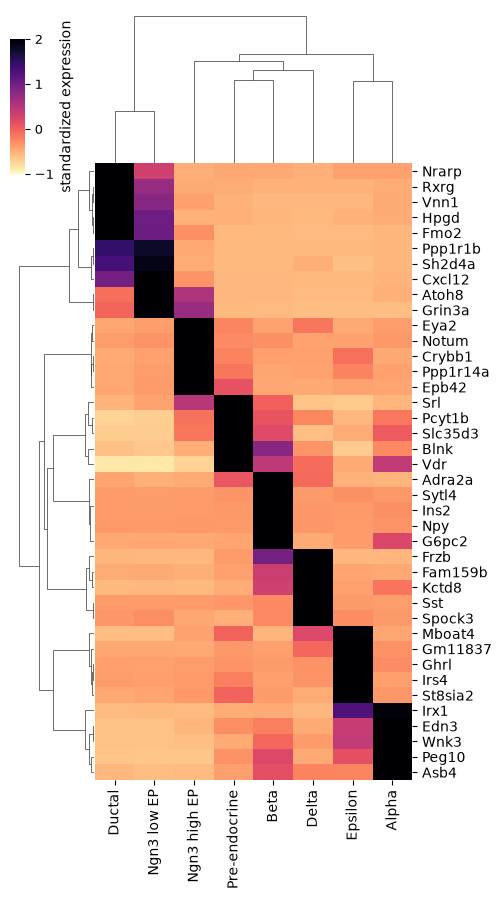

In [31]:
ds.plots.marker_heatmap(
    marker=marker_ref,
    cell_key='I',
    group_key='clusters',
    topn=5,
    figsize=(5, 9),
)

In [32]:
markers_csv = 'scarf_datasets/pancreas_cluster_markers.csv'
ds.export_markers_to_csv(
    marker=marker_ref,
    cell_key='I',
    group_key='clusters',
    csv_filename=markers_csv,
    min_score=0.1,
    min_frac_exp=0.1,
)
pd.read_csv(markers_csv).iloc[:5, :6]

,Alpha,Beta,Delta,Ductal,Epsilon,Ngn3 high EP
0,Asb4,Sytl4,Sst,Nrarp,Gm11837,Notum
1,Peg10,Ins2,Fam159b,Hpgd,Ghrl,Ppp1r14a
2,Wnk3,G6pc2,Kctd8,Vnn1,St8sia2,Crybb1
3,Irx1,Npy,Spock3,Fmo2,Irs4,Epb42
4,Edn3,Adra2a,Frzb,Rxrg,Mboat4,Eya2
